In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# Loading data
df_train = pd.read_csv('/content/train_num_data.csv')
df_test = pd.read_csv('/content/test_num_data.csv')

# Isolate the target variable
y_train = df_train['label']
y_test = df_test['label']

print(df_train.shape)
print(df_test.shape)

(32345, 7)
(8087, 7)


In [ ]:
#checking the dataframes
print(df_train.head())
print(y_train)
print(df_test.head())
print(y_test)

   char_count  word_count  punct_density  cap_ratio  rating  \
0         207          41       0.014423        0.0     4.0   
1         111          22       0.008929        0.0     3.0   
2         132          25       0.037594        0.0     5.0   
3          80          16       0.024691        0.0     5.0   
4         354          66       0.014085        0.0     1.0   

                       category  label  
0                Kindle_Store_5      1  
1                       Books_5      0  
2  Clothing_Shoes_and_Jewelry_5      0  
3                       Books_5      1  
4               Movies_and_TV_5      0  
0        1
1        0
2        0
3        1
4        0
        ..
32340    1
32341    0
32342    1
32343    0
32344    0
Name: label, Length: 32345, dtype: int64
   char_count  word_count  punct_density  cap_ratio  rating  \
0          90          16       0.021978        0.0     5.0   
1          85          15       0.058140        0.0     5.0   
2          98          2

In [ ]:
#encoding and normalisation
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = MinMaxScaler()

# FIT only on train, transform both
train_cat = ohe.fit_transform(df_train[['category']])
test_cat = ohe.transform(df_test[['category']])

# Process Numerical Data
num_cols = ['char_count', 'word_count', 'punct_density', 'cap_ratio', 'rating']
# FIT only on train, transform both
train_num = scaler.fit_transform(df_train[num_cols])
test_num = scaler.transform(df_test[num_cols])

# Assemble final feature matrices
X_train = np.hstack((train_cat, train_num))
X_test = np.hstack((test_cat, test_num))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (32345, 15)
X_test shape: (8087, 15)


In [ ]:
#checking the dataframes
print(X_train)
print(X_test)

[[0.         0.         0.         ... 0.01606206 0.         0.75      ]
 [1.         0.         0.         ... 0.00994318 0.         0.5       ]
 [0.         1.         0.         ... 0.04186603 0.         1.        ]
 ...
 [0.         0.         0.         ... 0.04296989 0.         0.5       ]
 [0.         0.         0.         ... 0.03424283 0.         0.75      ]
 [0.         0.         0.         ... 0.01781818 0.         1.        ]]
[[0.         0.         0.         ... 0.02447552 0.         1.        ]
 [0.         0.         0.         ... 0.0647463  0.         1.        ]
 [0.         1.         0.         ... 0.03374656 0.         1.        ]
 ...
 [0.         1.         0.         ... 0.0206229  0.         1.        ]
 [0.         0.         0.         ... 0.04105572 0.         1.        ]
 [0.         0.         0.         ... 0.03607893 0.         1.        ]]


In [ ]:
#training the XG_Boost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import pandas as pd

#Initialize and Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)

#Evaluate Performance
y_pred = xgb_model.predict(X_test)
y_proba_test = xgb_model.predict_proba(X_test)[:, 1]
y_proba_train = xgb_model.predict_proba(X_train)[:, 1]

Training XGBoost model...


In [ ]:
#results of XG_Boost model
print("\n--- XGBoost Branch (Standalone) Performance ---")
print(classification_report(y_test, y_pred, target_names=['Human (OR)', 'AI (CG)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_test):.4f}\n")


--- XGBoost Branch (Standalone) Performance ---
              precision    recall  f1-score   support

  Human (OR)       0.72      0.70      0.71      4044
     AI (CG)       0.71      0.72      0.72      4043

    accuracy                           0.71      8087
   macro avg       0.71      0.71      0.71      8087
weighted avg       0.71      0.71      0.71      8087

ROC-AUC Score: 0.7942



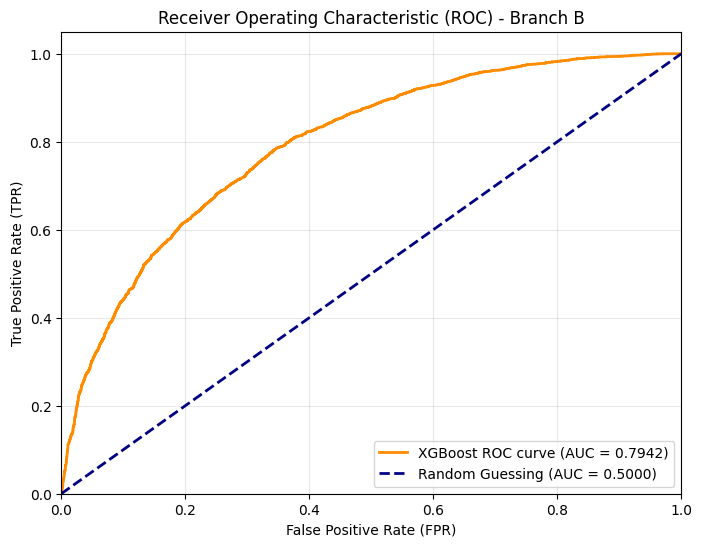

In [ ]:
#roc- auc curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC curve (AUC = {roc_auc:.4f})')

# Plot the baseline (random guessing)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')

# 4. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Branch B')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Display the plot
plt.show()

In [ ]:
#saving probs and models
import joblib

# We save these as DataFrames so we keep the exact index alignments
train_probs_df = pd.DataFrame({'xgb_prob': y_proba_train}, index=df_train.index)
test_probs_df = pd.DataFrame({'xgb_prob': y_proba_test}, index=df_test.index)

train_probs_df.to_csv('train_xgb_probabilities.csv', index=False)
test_probs_df.to_csv('test_xgb_probabilities.csv', index=False)
print("Saved probability arrays.")

# XGBoost has a native save method which is highly efficient
xgb_model.save_model('branch_b_xgboost.json')

# We use joblib to save the fitted scaler and encoder
joblib.dump(scaler, 'branch_b_scaler.joblib')
joblib.dump(ohe, 'branch_b_ohe.joblib')
print("Saved XGBoost model, Scaler, and OneHotEncoder.")

Saved probability arrays.
Saved XGBoost model, Scaler, and OneHotEncoder.
